# Analiza podatkov iz knjige Orgle Slovenije


## Uvažanje potrebnih knjižnic in modulov


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from orodja.pridobivanje_podatkov import pridobi_orglarje
from orodja.zapisovanje_podatkov import zapisi_orglarje_v_csv
from orodja.filtriranje_podatkov import *

## Pridobivanje in zapisovanje podatkov

In [2]:
orglarji = pridobi_orglarje()
zapisi_orglarje_v_csv(orglarji)

org = pd.read_csv('podatki/orglarji.csv')

*Podrobnejši opis strukture podatkov se nahaja v datoteki [`README.md`](README.md#struktura-podatkov).*

## Analiza

### Spreminjanje števila orglarjev na slovenskem območju

Območja delovanja orglarja nam povedo v kateri regiji je bil orglar najbolj aktiven. V primeru, da je teh območij več, lahko sklepamo, da je bil povsod podobno aktiven; vendar zaradi oblike pridobljenih podatkov ne moremo sklepati v katerem območju je bil orglar prevalenten v določenem časovnem obdobju. To dejstvo bomo šteli kot manjšo napako, saj je večina orglarjev delovala le v enem območju.

Pod slovenska območja bomo šteli regije, ki so v mejah sedanje Slovenije:
   - LJ: Ljubljana z okolico in Gorenjska,
   - MB: Maribor in Podravje,
   - CE: Savinjska,
   - NM: Dolenjska,
   - GO: Goriška,
   - KO: Koroška.

Aktivnost orglarjev smo gledali po desetletnih obdobjih:

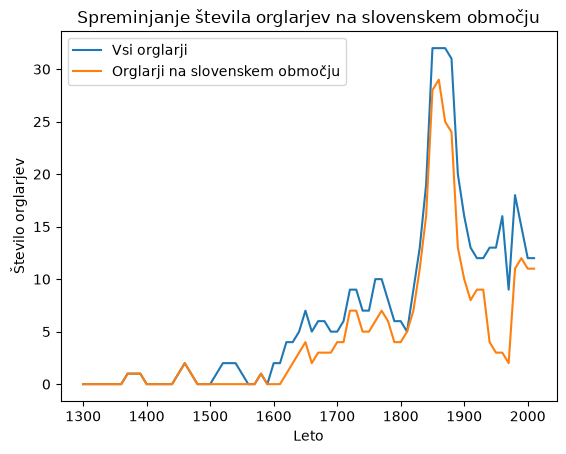

In [3]:
# Sestavimo seznam orglarjev po desetletjih
ZACETEK, KONEC = 1300, 2020
org_po_deset = pridobi_orglarje_po_desetletjih(org, ZACETEK, KONEC)

# Pridobimo orglarje na slovenskem območju
SLOVENSKA_OBMOCJA = ["LJ", "MB", "CE", "NM", "GO", "KO"]
org_po_deset_slo = [
    pridobi_orglarje_v_obmocjih(o, SLOVENSKA_OBMOCJA)
    for o in org_po_deset
]

# Preštejemo število orglarjev
st_org = list(map(len, org_po_deset))
st_org_slo = list(map(len, org_po_deset_slo))

# Izrišemo graf
desetl = range(ZACETEK, KONEC, 10)
plt.plot(desetl, st_org, label="Vsi orglarji")
plt.plot(desetl, st_org_slo, label="Orglarji na slovenskem območju")

# Nastavimo prikaz grafa
plt.title("Spreminjanje števila orglarjev na slovenskem območju")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

*Orglarja Georgius de Venetia iz leta 826 smo izpustili zaradi preglednosti grafa.*

#### Interpretacija

- Število orglarjev na slovenskih in tujih območjih se je večinoma spreminjalo v istem gibanju.
- Največ orglarjev je delovalo v drugi polovici 19. stoletja.
- V času prve in druge svetovne vojne se je število orglarjev izrazito zmanjšalo.
- V času vojen je na slovenskem območju orglarska obrt bolj zakrnela v primerjavi s tujimi območji.


### Spreminjanje števila orglarjev po območjih

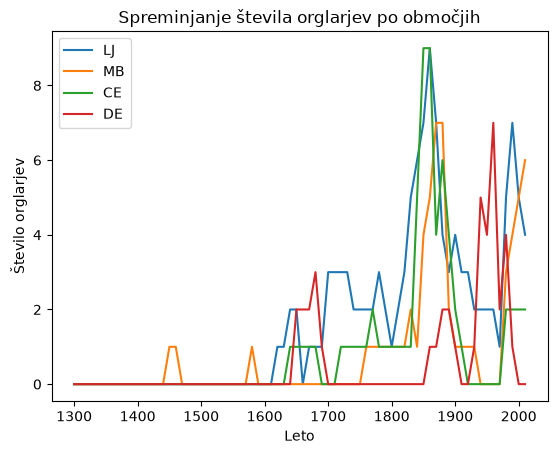

In [4]:
VSA_OBMOCJA = [
    "AT", "CE", "CZ", "DN", "NM", "GO", "GR",
    "HR", "IT", "KO", "LJ", "HU", "DE", "NL",
    "MB", "SW", "CH", "TS", "GB"
]

# Sestavimo seznam orglarjev po območjih
org_po_obm = [
    (obmocje, pridobi_orglarje_v_obmocjih(org, [obmocje]))
    for obmocje in VSA_OBMOCJA
]

# Območja uredimo glede na število orglarjev
org_po_obm.sort(reverse=True, key=lambda x: len(x[1]))

# Vzamemo 4 območja z največ orglarji
for obm, org_obm in org_po_obm[:4]:

    # Pridobimo in preštejemo število orglarjev po desetletjih
    org_po_deset = pridobi_orglarje_po_desetletjih(org_obm, ZACETEK, KONEC)
    st_org_ = list(map(len, org_po_deset))

    # Izrišemo v isti graf
    plt.plot(desetl, st_org_, label=obm)

# Nastavimo prikaz grafa
plt.title("Spreminjanje števila orglarjev po območjih")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');


*Zaradi preglednosti smo izbrali le 4 območja z največ orglarji, ki so se izkazala za:*

1. LJ: Ljubljana z okolico in Gorenjska,
2. MB: Maribor in Podravje,
3. CE: Savinjska,
4. DE: Nemčija.

#### Intepretacija

- Število orglarjev na slovenskem območju se je gibalo v drugačnem toku kot v Nemčiji.
- Nemške delavnice so najbolj aktivne v času vojen, ko nazadujejo slovenski orglarji.
- Ob koncu 20. stoletja je orglarska obrt na slovenskem območju ponovno zaživela.
- V 21. stoletju začnejo ponovno prevladovati orglarji na slovenskem območju.


### Spreminjanje števila orglarjev z domnevnim obdobjem

Pri nekaterih (6) orglarjih je letnica njihovega prvega ali zadnjega opusa domnevna. Kje se le-ti nahajajo nam bo pokazala razlika v grafu vseh orglarjev in nedomnevnih orglarjev (orglarjev brez domnevnih letnic):

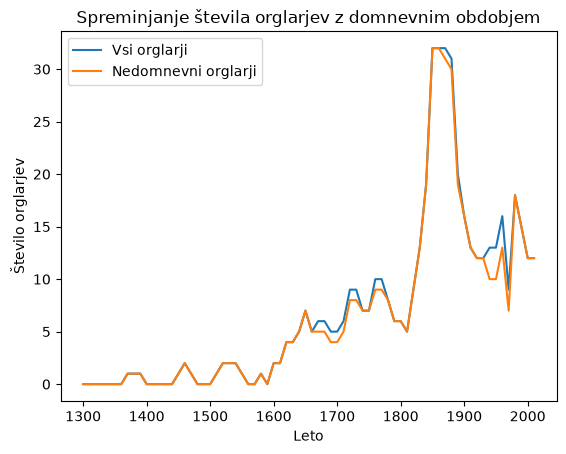

In [5]:
# Sestavimo seznam nedomnevnih orglarjev po desetletjih
org_po_deset_nedom = pridobi_orglarje_po_desetletjih(org, ZACETEK, KONEC, glej_domnevno=False)

# Preštejemo število nedomnevnih orglarjev
st_org_nedom = list(map(len, org_po_deset_nedom))

# Izrišemo graf
plt.plot(desetl, st_org, label="Vsi orglarji")
plt.plot(desetl, st_org_nedom, label="Nedomnevni orglarji")

# Nastavimo prikaz grafa
plt.title("Spreminjanje števila orglarjev z domnevnim obdobjem")
plt.xlabel("Leto")
plt.ylabel("Število orglarjev")
plt.legend(loc='upper left');

#### Interpretacija

V času vojen je orglarjev z domnevnim obdobjem naraslo. Razlagamo si lahko da je to zato, ker so zaradi situacije uvažali orgle iz drugod in ni bilo vedno jasno zapisano kdaj so prišle.


### Najdlje aktivni orglarji


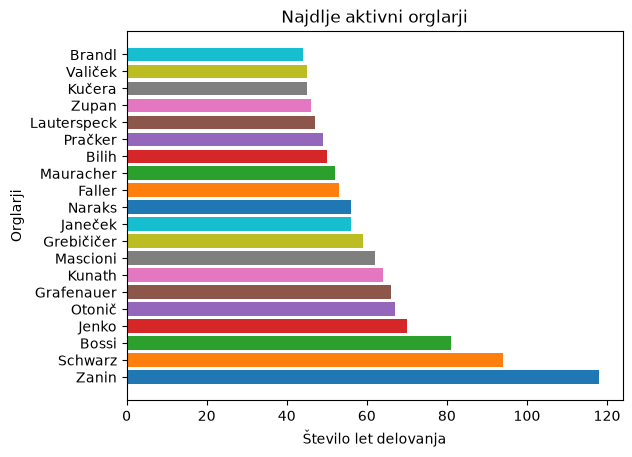

In [6]:
# Sestavimo seznam orglarjev z njihovim časom delovanja
org_akt = [
    (naziv, konec - zacetek)
    for naziv, zacetek, konec in zip(org.kratek_naziv, org.zacetek_aktivnosti, org.konec_aktivnosti)
]

# Orglarje uredimo glede na čas delovanja
org_akt.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 najdlje aktivnih orglarjev v diagram
for naziv, cas_akt in org_akt[:20]:
    plt.barh(naziv, cas_akt)

# Nastavimo prikaz diagrama
plt.title("Najdlje aktivni orglarji")
plt.xlabel("Število let delovanja")
plt.ylabel("Orglarji");

#### Interpretacija

Vseh 5 najdlje aktivnih orglarskih delavnic je delovalo več kot 60 let. Iz tega lahko sklepamo, da so se pri njih zvrstili vsaj 2 generaciji orglarjev.


### Največkrat omenjeni orglarji

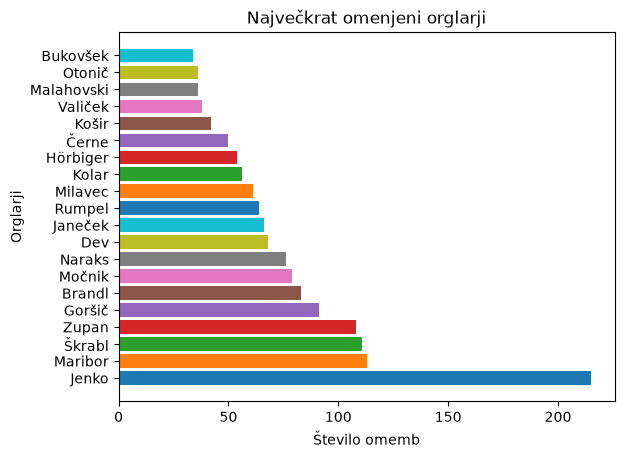

In [7]:
# Sestavimo seznam orglarjev s številom omemb
org_om = [
    (naziv, len(eval(strani)))
    for naziv, strani in zip(org.kratek_naziv, org.strani_z_omembo)
]

# Orglarje uredimo glede na število omemb
org_om.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 največkrat omenjenih orglarjev v diagram
for naziv, st_om in org_om[:20]:
    plt.barh(naziv, st_om)

# Nastavimo prikaz diagrama
plt.title("Največkrat omenjeni orglarji")
plt.xlabel("Število omemb")
plt.ylabel("Orglarji");

#### Interpretacija

Največkrat so omenjeni slovenski orglarji, zato lahko sklepamo, da je največ opusov v knjigi iz rok le-teh.


### Število omemb orglarjev po straneh

Knjiga vsebuje 678 strani v katerih je zapisana: zgodovina, dediščina, statistika in zemljevidi orgel po vsej Sloveniji. Omembe so razporejene glede na sledeči diagram:


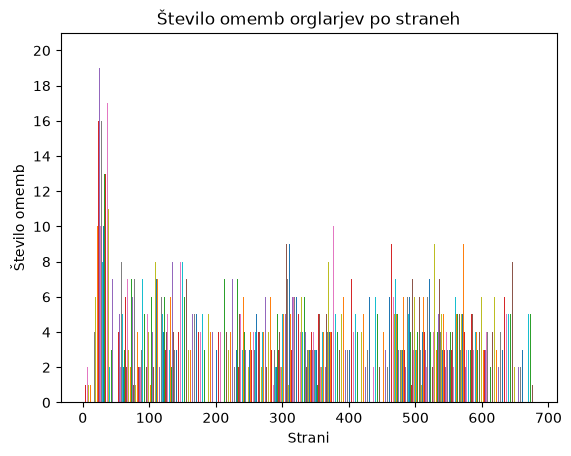

In [8]:
STEVILO_STRANI = 678

# Sestavimo seznam strani s številom omemb
om_po_stran = [
    (s, len(pridobi_omenjene_orglarje(org, s)))
    for s in range(1, STEVILO_STRANI + 1)
]

# Zapišemo strani s številom omemb v diagram
for stran, st_om in om_po_stran:
    plt.bar(stran, st_om)

# Nastavimo prikaz diagrama
plt.title("Število omemb orglarjev po straneh")
plt.xlabel("Strani")
plt.ylabel("Število omemb")
plt.yticks(range(0, 21, 2));

#### Interpretacija

- Največ omemb je v uvodnem delu knjige, kjer se nahaja zgodovinski pregled.
- Največ omemb ima stran 35 in to 20.
- Povprečno je v knjigi 4 omemb na stran.

Zanimivi sta strani 377 in 466, kjer se nahaja kar 10 omemb različnih orglarjev, čeprav se ne nahajata v zgodovinskem predelu knjige.


### Povezava med začetkom aktivnosti in številom omemb orglarjev


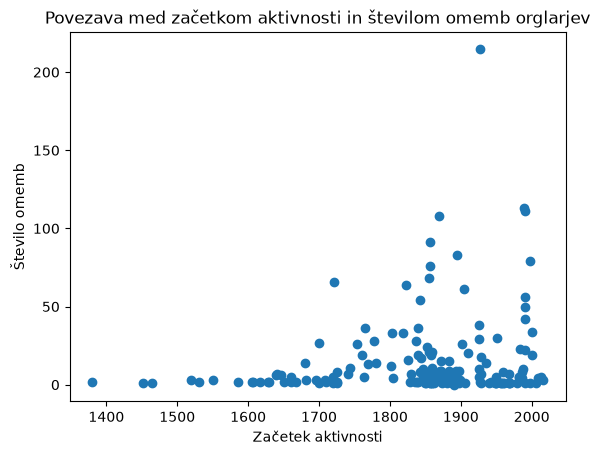

In [9]:
# Spustimo orglarje pred letom 1300
org_zac = org[org.zacetek_aktivnosti > ZACETEK]

# Zapišemo lastnosti orglarjev v graf raztrosa
plt.scatter(
    org_zac.zacetek_aktivnosti,
    [len(eval(s)) for s in org_zac.strani_z_omembo],
)

# Nastavimo prikaz grafa
plt.title("Povezava med začetkom aktivnosti in številom omemb orglarjev")
plt.xlabel("Začetek aktivnosti")
plt.ylabel("Število omemb");

#### Interpretacija

Graf raztrosa spominja na graf števila vseh orglarjev skozi čas. Tako lahko sklepamo, da je večje število orglarjev doprineslo k večjemu številu omemb posameznih orglarjev. Prav tako lahko v 21. stoletju zaznamo večjo aktivnost slovenskih orglarjev, saj so nadpovprečno omenjeni.

### Orglarji z največ drugih nazivov


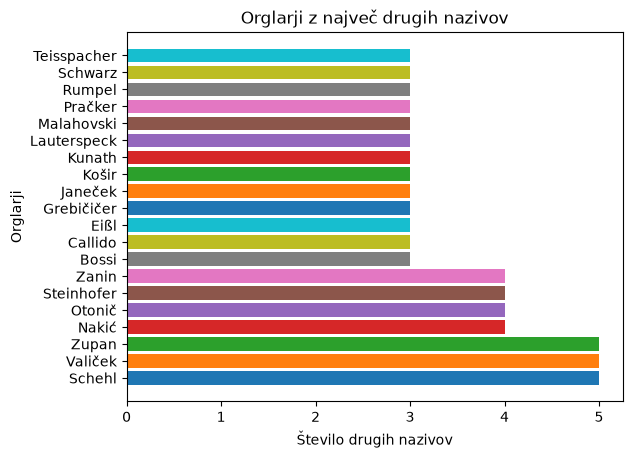

In [10]:
# Sestavimo seznam orglarjev s številom nazivov
org_naz = [
    (naziv, len(eval(drugi_nazivi)))
    for naziv, drugi_nazivi in zip(org.kratek_naziv, org.drugi_nazivi)
]

# Orglarje uredimo glede na število nazivov
org_naz.sort(reverse=True, key=lambda x: x[1])

# Zapišemo 20 orglarjev z največ nazivi v diagram
for naziv, st_naz in org_naz[:20]:
    plt.barh(naziv, st_naz)

# Nastavimo prikaz diagrama
plt.title("Orglarji z največ drugih nazivov")
plt.xlabel("Število drugih nazivov")
plt.ylabel("Orglarji");

#### Interpretacija

Ker v seznamu drugih nazivov nismo ločevali med: celim imenom, drugimi zapisi imena, sodelavci, nasledniki ... iz števila nazivov ne moremo nič sklepati. Tak način shranjevanja podatkov je bil načrtovan že od začetka, saj iz izvirnika ne moremo vedno ločiti med možnostmi, omenjenimi v prejšnji povedi.

### Povezava med začetkom aktivnosti in številom drugih nazivov orglarjev


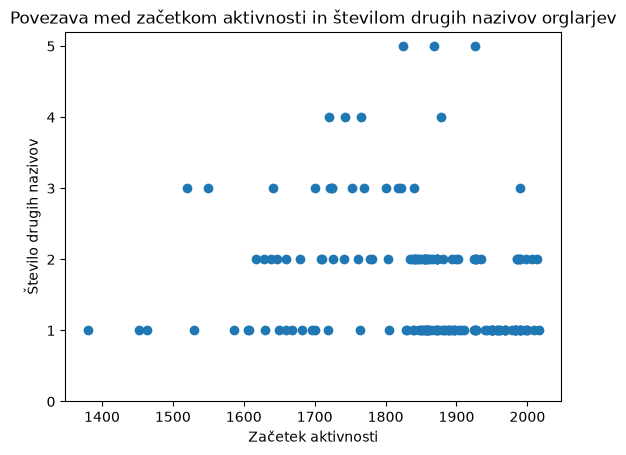

In [11]:
# Zapišemo lastnosti orglarjev v graf raztrosa
plt.scatter(
    org_zac.zacetek_aktivnosti,
    [len(eval(n)) for n in org_zac.drugi_nazivi],
)

# Nastavimo prikaz grafa
plt.title("Povezava med začetkom aktivnosti in številom drugih nazivov orglarjev")
plt.xlabel("Začetek aktivnosti")
plt.ylabel("Število drugih nazivov")
plt.yticks(range(0, 6));

#### Interpretacija

V povprečju je največ drugih nazivov pripisanim orglarjem v 18. stoletju. Sklepamo, da je to zaradi pogostih različnih zapisov imen, ki so nastali v poznejših obdobjih.